0. Przetestowanie działania biblioteki pymc

In [12]:
import pymc as pm

# Taking draws from a normal distribution
seed = 42
x_dist = pm.Normal.dist(shape=(100, 3))
x_data = pm.draw(x_dist, random_seed=seed)

# Define coordinate values for all dimensions of the data
coords={
 "trial": range(100),
 "features": ["sunlight hours", "water amount", "soil nitrogen"],
}

# Define generative model
with pm.Model(coords=coords) as generative_model:
   x = pm.Data("x", x_data, dims=["trial", "features"])

   # Model parameters
   betas = pm.Normal("betas", dims="features")
   sigma = pm.HalfNormal("sigma")

   # Linear model
   mu = x @ betas

   # Likelihood
   # Assuming we measure deviation of each plant from baseline
   plant_growth = pm.Normal("plant growth", mu, sigma, dims="trial")


# Generating data from model by fixing parameters
fixed_parameters = {
 "betas": [5, 20, 2],
 "sigma": 0.5,
}
with pm.do(generative_model, fixed_parameters) as synthetic_model:
   idata = pm.sample_prior_predictive(random_seed=seed) # Sample from prior predictive distribution.
   synthetic_y = idata.prior["plant growth"].sel(draw=0, chain=0)


# Infer parameters conditioned on observed data
with pm.observe(generative_model, {"plant growth": synthetic_y}) as inference_model:
   idata = pm.sample(random_seed=seed)

   summary = pm.stats.summary(idata, var_names=["betas", "sigma"])
   print(summary)

Sampling: [plant growth]
Initializing NUTS using jitter+adapt_diag...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, sigma]
NUTS: [betas, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 40 seconds.


                         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
betas[sunlight hours]   4.973  0.053   4.872    5.071      0.001    0.001   
betas[water amount]    19.964  0.049  19.871   20.055      0.001    0.001   
betas[soil nitrogen]    1.996  0.056   1.895    2.100      0.001    0.001   
sigma                   0.511  0.037   0.445    0.582      0.000    0.001   

                       ess_bulk  ess_tail  r_hat  
betas[sunlight hours]    5469.0    3527.0    1.0  
betas[water amount]      5776.0    3157.0    1.0  
betas[soil nitrogen]     4913.0    3428.0    1.0  
sigma                    5603.0    3476.0    1.0  


#### 1. Plot Gaussian probability density function for a couple of different standard deviations in range from 0.2 to 2 (all in one plot). Label the axes appropriately.

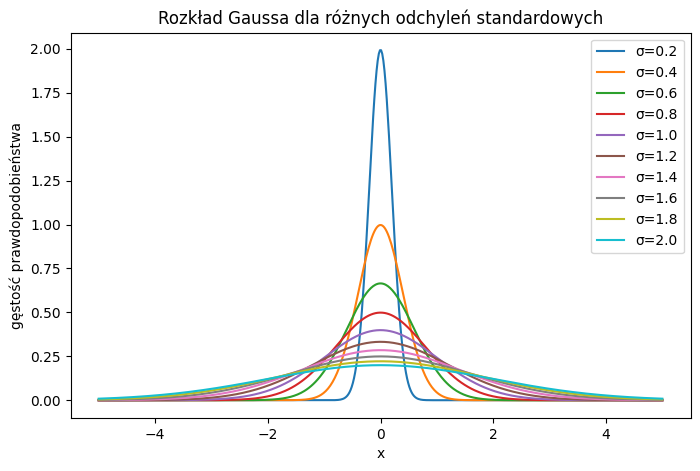

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Zakres wartości x
x = np.linspace(-5, 5, 500)

# Standard deviations to plot
std_devs = np.linspace(0.2, 2, 10)

plt.figure(figsize=(8, 5))
for std in std_devs:
    plt.plot(x, norm.pdf(x, loc=0, scale=std), label=f'σ={std:.1f}')

plt.xlabel('x')
plt.ylabel('gęstość prawdopodobieństwa')
plt.title('Rozkład Gaussa dla różnych odchyleń standardowych')
plt.legend()
plt.show()

#### 2. Plot Gaussian cumulative density function for a couple of different standard deviations in range from 0.2 to 2 (all in one plot). Label the axes appropriately.

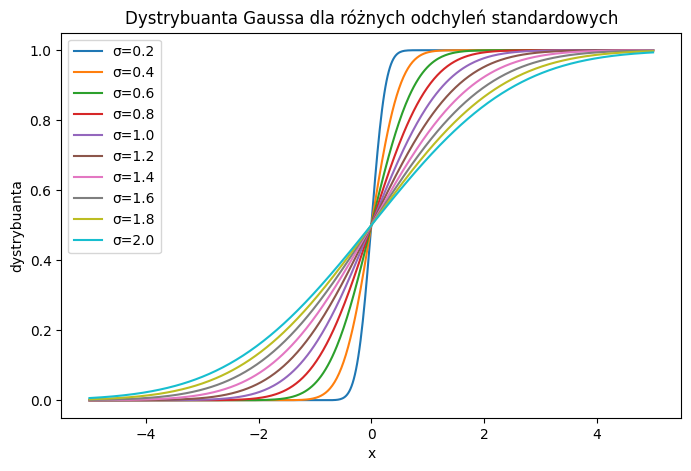

In [6]:
# Wykres funkcji gęstości skumulowanej Gaussa dla różnych odchyleń standardowych
plt.figure(figsize=(8, 5))
for std in std_devs:
    plt.plot(x, norm.cdf(x, loc=0, scale=std), label=f'σ={std:.1f}')

plt.xlabel('x')
plt.ylabel('dystrybuanta')
plt.title('Dystrybuanta Gaussa dla różnych odchyleń standardowych')
plt.legend()
plt.show()

#### 3. Plot as in 2 and 3, but make two subplots in one plot: the top containing pdfs, the bottom containing cdfs

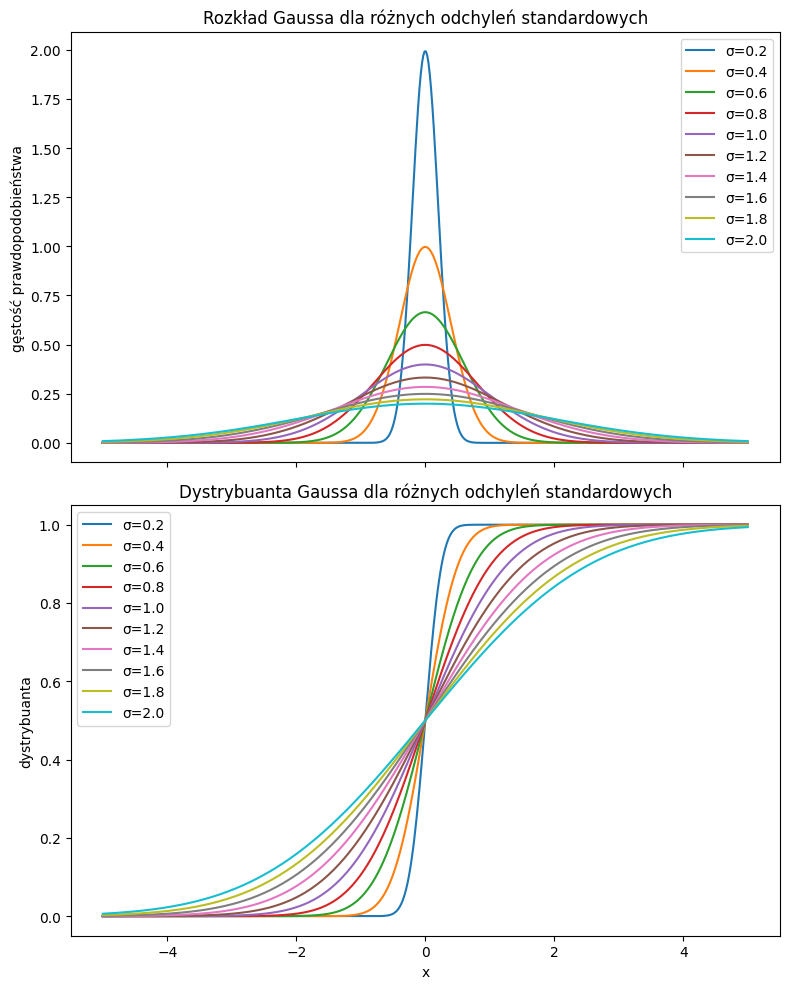

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# PDF subplot (top)
for std in std_devs:
    axs[0].plot(x, norm.pdf(x, loc=0, scale=std), label=f'σ={std:.1f}')
axs[0].set_ylabel('gęstość prawdopodobieństwa')
axs[0].set_title('Rozkład Gaussa dla różnych odchyleń standardowych')
axs[0].legend()

# CDF subplot (bottom)
for std in std_devs:
    axs[1].plot(x, norm.cdf(x, loc=0, scale=std), label=f'σ={std:.1f}')
axs[1].set_xlabel('x')
axs[1].set_ylabel('dystrybuanta')
axs[1].set_title('Dystrybuanta Gaussa dla różnych odchyleń standardowych')
axs[1].legend()

plt.tight_layout()
plt.show()

#### 4. Plot binomial probability mass function for Bi(10, 0.5) and Bi(10, 0.1). Plot both in one plot (not subplots). Use red dots for the first one, green crosses for the second one. Add legend to the plot.

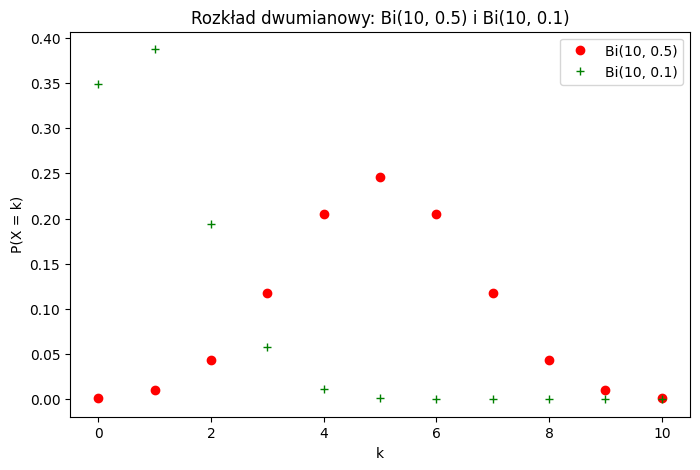

In [10]:
import numpy as np
from scipy.stats import binom

import matplotlib.pyplot as plt

# Parametry rozkładów
n = 10
p1 = 0.5
p2 = 0.1

# Wartości k
k = np.arange(0, n + 1)

# PMF dla obu rozkładów
pmf1 = binom.pmf(k, n, p1)
pmf2 = binom.pmf(k, n, p2)

plt.figure(figsize=(8, 5))
plt.plot(k, pmf1, 'ro', label='Bi(10, 0.5)')
plt.plot(k, pmf2, 'g+', label='Bi(10, 0.1)')
plt.xlabel('k')
plt.ylabel('P(X = k)')
plt.title('Rozkład dwumianowy: Bi(10, 0.5) i Bi(10, 0.1)')
plt.legend()
plt.show()

#### 5. Plot Poisson probability mass function for several values of the parameter, all in one plot. Use continuous line with crosses at data points. Add legend to the plot.

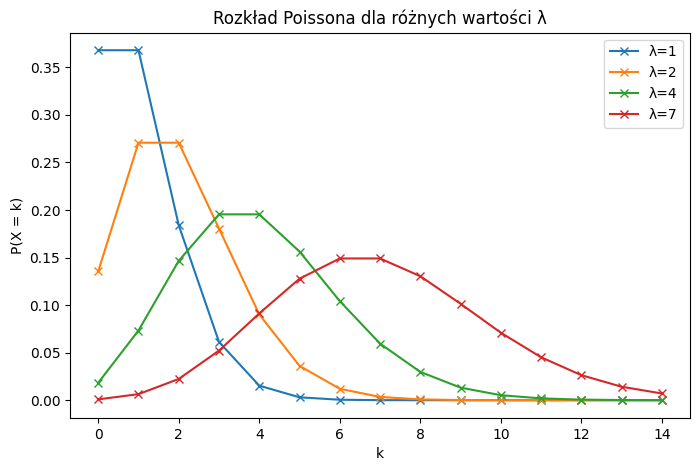

In [11]:
from scipy.stats import poisson

# Parametry lambda do wykresu
lambdas = [1, 2, 4, 7]
k_vals = np.arange(0, 15)

plt.figure(figsize=(8, 5))
for lam in lambdas:
    pmf = poisson.pmf(k_vals, lam)
    plt.plot(k_vals, pmf, marker='x', label=f'λ={lam}')
plt.xlabel('k')
plt.ylabel('P(X = k)')
plt.title('Rozkład Poissona dla różnych wartości λ')
plt.legend()
plt.show()